# Results section graphics

This notebook creates the main result visualizations from the saved evaluation outputs:

1. A grouped bar chart comparing Baseline ResNet50, Base model, and Cancer Expert.
2. Full 9-class confusion matrices for Baseline ResNet50 and Cancer Expert.
3. Cancer-vs-rest confusion matrices for Baseline ResNet50 and Cancer Expert.

All metrics are computed from the saved confusion matrices so the figures stay consistent with the displayed counts.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "report" / "figures"
SAVE_FIGURES = False

SYSTEMS = {
    "Baseline ResNet50": RESULTS_DIR / "baseline_resnet50" / "confusion_matrix.csv",
    "Base model": RESULTS_DIR / "basemodel" / "confusion_matrix.csv",
    "Cancer Expert": RESULTS_DIR / "cancer_expert" / "confusion_matrix.csv",
}

CLASS_LABELS = [
    "adipose",
    "background",
    "debris",
    "lymphocytes",
    "mucus",
    "smooth muscle",
    "mucosa",
    "stroma",
    "epithelium",
]
CANCER_INDICES = [7, 8]
STROMA_INDEX = 7
EPITHELIUM_INDEX = 8

In [2]:
def load_confusion_matrix(path: Path) -> np.ndarray:
    return pd.read_csv(path, index_col=0).to_numpy(dtype=int)


def safe_divide(numerator: np.ndarray | float, denominator: np.ndarray | float) -> np.ndarray | float:
    return np.divide(numerator, denominator, out=np.zeros_like(numerator, dtype=float), where=denominator != 0)


def precision_recall_fbeta_from_cm(cm: np.ndarray, beta: float = 2.0) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    tp = np.diag(cm).astype(float)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    precision = safe_divide(tp, tp + fp)
    recall = safe_divide(tp, tp + fn)
    beta2 = beta**2
    fbeta = safe_divide((1 + beta2) * precision * recall, beta2 * precision + recall)
    return precision, recall, fbeta


def collapse_to_cancer_vs_rest(cm: np.ndarray, cancer_indices: list[int] = CANCER_INDICES) -> np.ndarray:
    cancer = np.array(cancer_indices)
    rest = np.array([i for i in range(cm.shape[0]) if i not in cancer_indices])
    return np.array([
        [cm[np.ix_(rest, rest)].sum(), cm[np.ix_(rest, cancer)].sum()],
        [cm[np.ix_(cancer, rest)].sum(), cm[np.ix_(cancer, cancer)].sum()],
    ], dtype=int)


def metrics_from_cm(cm: np.ndarray) -> dict[str, float]:
    _, recall, f2 = precision_recall_fbeta_from_cm(cm, beta=2.0)
    binary_cm = collapse_to_cancer_vs_rest(cm)
    _, binary_recall, binary_f2 = precision_recall_fbeta_from_cm(binary_cm, beta=2.0)
    return {
        "Overall Accuracy": np.trace(cm) / cm.sum(),
        "Overall Recall": recall.mean(),
        "Overall F2": f2.mean(),
        "Cancer vs. Rest Recall": binary_recall[1],
        "Cancer vs. Rest F2": binary_f2[1],
        "Stroma Recall": recall[STROMA_INDEX],
        "Stroma F2": f2[STROMA_INDEX],
        "Epithelium Recall": recall[EPITHELIUM_INDEX],
        "Epithelium F2": f2[EPITHELIUM_INDEX],
    }


confusion_matrices = {name: load_confusion_matrix(path) for name, path in SYSTEMS.items()}
metric_table = pd.DataFrame({name: metrics_from_cm(cm) for name, cm in confusion_matrices.items()}).T
metric_table.round(4)

,Overall Accuracy,Overall Recall,Overall F2,Cancer vs. Rest Recall,Cancer vs. Rest F2,Stroma Recall,Stroma F2,Epithelium Recall,Epithelium F2
Baseline ResNet50,0.9238,0.8981,0.8966,0.8888,0.9029,0.5439,0.5917,0.9667,0.9605
Base model,0.9057,0.8886,0.8850,0.9160,0.9172,0.5202,0.5688,0.9886,0.9623
Cancer Expert,0.9259,0.9295,0.9255,0.9800,0.9652,0.9311,0.9087,0.9830,0.9712


## Metric comparison bar chart

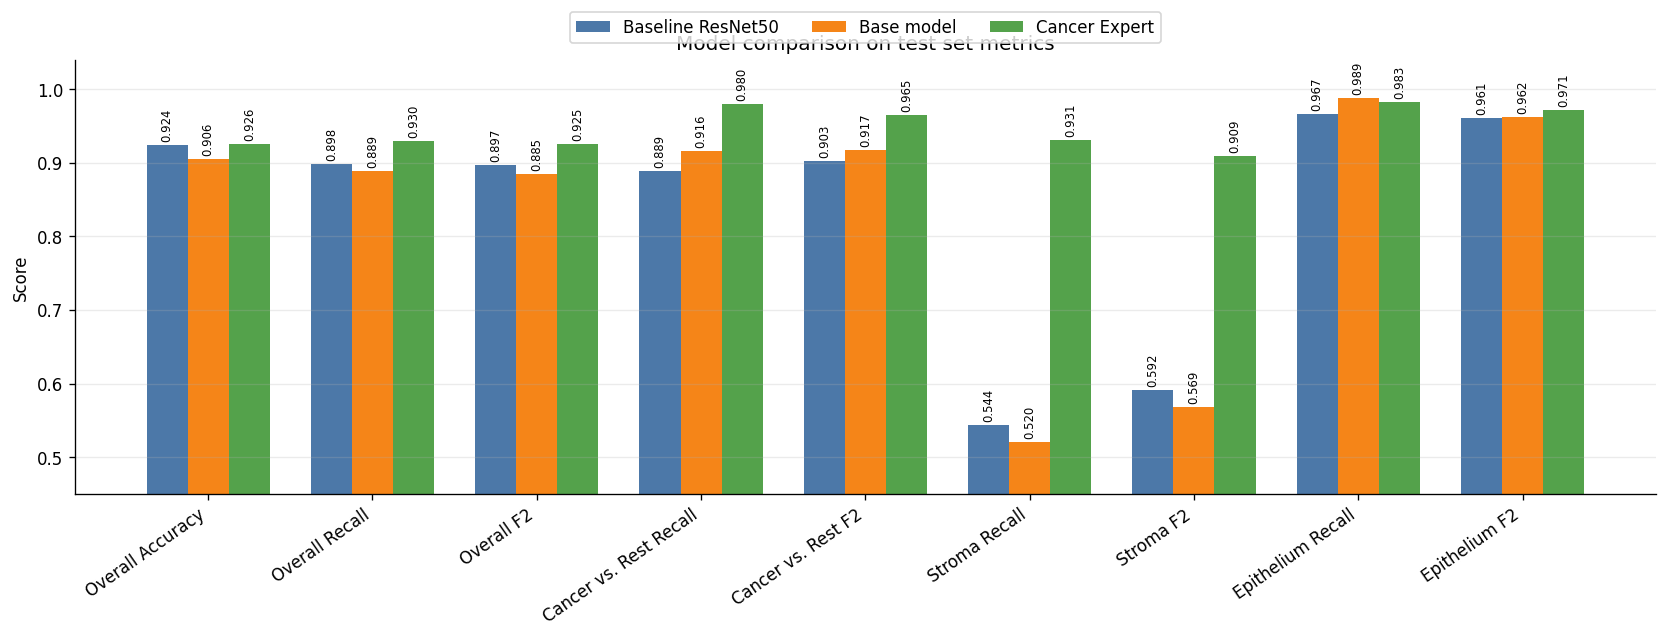

In [3]:
metric_order = [
    "Overall Accuracy",
    "Overall Recall",
    "Overall F2",
    "Cancer vs. Rest Recall",
    "Cancer vs. Rest F2",
    "Stroma Recall",
    "Stroma F2",
    "Epithelium Recall",
    "Epithelium F2",
]
system_order = ["Baseline ResNet50", "Base model", "Cancer Expert"]
colors = ["#4C78A8", "#F58518", "#54A24B"]

x = np.arange(len(metric_order))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 5.5))
for offset, system, color in zip([-width, 0, width], system_order, colors):
    values = metric_table.loc[system, metric_order].to_numpy()
    bars = ax.bar(x + offset, values, width=width, label=system, color=color)
    ax.bar_label(bars, labels=[f"{v:.3f}" for v in values], padding=2, rotation=90, fontsize=7)

ax.set_title("Model comparison on test set metrics")
ax.set_ylabel("Score")
ax.set_ylim(0.45, 1.04)
ax.set_xticks(x)
ax.set_xticklabels(metric_order, rotation=35, ha="right")
ax.grid(axis="y", alpha=0.25)
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.13))
fig.tight_layout()

if SAVE_FIGURES:
    fig.savefig(FIGURES_DIR / "results_metric_comparison.svg", bbox_inches="tight")

## Full confusion matrices

Rows are true classes and columns are predicted classes. The numbers shown are raw test-set counts.

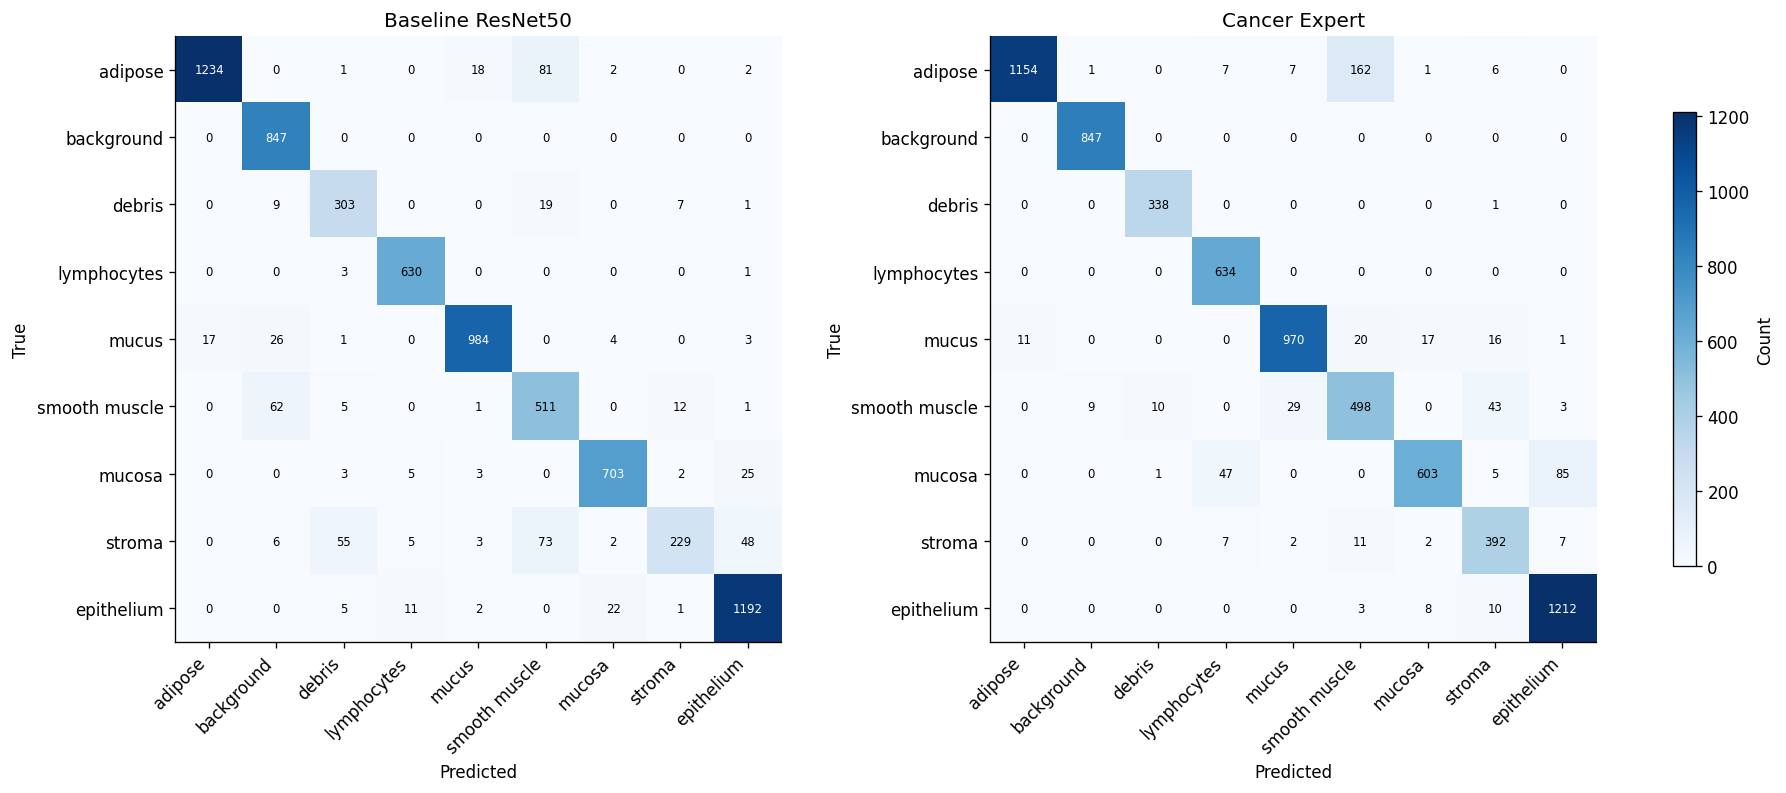

In [4]:
def plot_confusion_matrix(ax, cm: np.ndarray, labels: list[str], title: str, cmap: str = "Blues"):
    im = ax.imshow(cm, cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    threshold = cm.max() * 0.55
    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            color = "white" if cm[row, col] > threshold else "black"
            ax.text(col, row, str(cm[row, col]), ha="center", va="center", fontsize=7, color=color)
    return im


fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), constrained_layout=True)
for ax, system in zip(axes, ["Baseline ResNet50", "Cancer Expert"]):
    im = plot_confusion_matrix(ax, confusion_matrices[system], CLASS_LABELS, system)

fig.colorbar(im, ax=axes, shrink=0.75, label="Count")

if SAVE_FIGURES:
    fig.savefig(FIGURES_DIR / "results_resnet50_vs_cancer_expert_confusion_matrices.svg", bbox_inches="tight")

## Cancer-vs-rest confusion matrices

Here, stroma and epithelium are collapsed into one cancer class. All other classes are collapsed into rest.

Baseline ResNet50        Base model        Cancer Expert       
                    rest cancer       rest cancer          rest cancer
rest                5472     54       5398    128          5366    160
cancer               184   1470        139   1515            33   1621

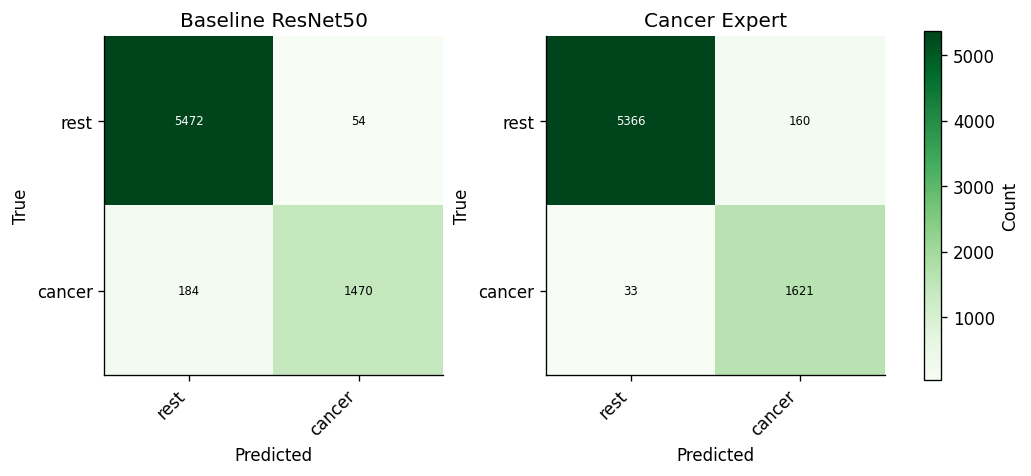

In [5]:
binary_labels = ["rest", "cancer"]
binary_matrices = {
    system: collapse_to_cancer_vs_rest(cm)
    for system, cm in confusion_matrices.items()
}

fig, axes = plt.subplots(1, 2, figsize=(8.5, 4), constrained_layout=True)
for ax, system in zip(axes, ["Baseline ResNet50", "Cancer Expert"]):
    im = plot_confusion_matrix(ax, binary_matrices[system], binary_labels, system, cmap="Greens")

fig.colorbar(im, ax=axes, shrink=0.85, label="Count")

if SAVE_FIGURES:
    fig.savefig(FIGURES_DIR / "results_resnet50_vs_cancer_expert_cancer_rest_confusion_matrices.svg", bbox_inches="tight")

pd.concat(
    {system: pd.DataFrame(cm, index=binary_labels, columns=binary_labels) for system, cm in binary_matrices.items()},
    axis=1,
)

## Additional result-figure ideas

A strong additional figure would be an **error-flow or correction plot** from the Base model to the Cancer Expert. The Cancer Expert was designed to recover cancer-related errors, so a figure showing recovered stroma false negatives, newly introduced stroma false positives, and epithelium-to-stroma changes would directly explain the tradeoff behind the metric gains.

Other useful options:

- A per-class recall/F2 heatmap for all three systems. This makes it clear whether the Cancer Expert improves only the target classes or also changes unrelated classes.
- A delta bar chart showing Cancer Expert minus Base model for every metric. This is easier to discuss than absolute values when the report focuses on improvement.
- A small table or plot of the most important stroma confusions before and after the Cancer Expert, especially stroma predicted as smooth muscle, debris, or epithelium.